# XGBoost Flight Delay Type Predictor
### Two-Year Combined Dataset (2023 + 2024)

This notebook trains an **XGBoost multi-class classifier** to predict the *primary cause* of a flight delay across multiple carriers.

| Label | Delay Type | Description |
|-------|-----------|-------------|
| **0** | No Delay | Dominant delay type below threshold |
| **1** | Carrier Delay | Airline controllable issues |
| **2** | Weather Delay | Extreme / significant weather |
| **3** | NAS Delay | National Aviation System |
| **4** | Late Aircraft Delay | Previous flight arrived late |
| **5** | Security Delay | Security screening or breach |

---
**All tuning knobs are in the CONFIG dictionary in Cell 1.**  
Set `run_tuning = True` to run a full `RandomizedSearchCV` hyperparameter sweep.


## Installation of Libraries

In [38]:
# Uncomment and run once if packages are not already installed
#%pip install xgboost scikit-learn matplotlib pandas numpy

## Step 1: Imports & Configuration

All tunable parameters live in CONFIG below — change values here, then re-run the notebook.


In [39]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
%matplotlib inline

# CONFIG (Tuneable Parameter)
CONFIG = {
    # Data
    "Airport_Data_2024":         "Delayed_Cancelled_Flights_sample.csv",
    "Airport_Data_2023":         "Delayed_Cancelled_Flights_2023sample.csv",
    "carrier_lookup":            "Carrier_Lookup.csv",  # key for airline codes
    "carrier_name":              "CARRIER_NAME",        # column in carrier_lookup with full names
    "min_delay_mins":    15,     # dominant delay < N min → label 0 (No Delay)
    "carrier_filter":    None,   # e.g. "WN" to train on one carrier; None = all
    "test_size":         0.20,   # fraction held out for final evaluation
    "random_state":      42,

    # XGBoost hyperparameters
    # Raise n_estimators and lower learning_rate together for better accuracy.
    # Raise max_depth carefully — too high overfits on small datasets.
    "n_estimators":      400,    # number of boosting rounds
    "learning_rate":     0.05,   # step size shrinkage (eta) — lower = slower but better
    "max_depth":         6,      # tree depth — 4-8 is a good range
    "min_child_weight":  3,      # min sum of instance weight in a child — higher = conservative
    "subsample":         0.80,   # row sampling per tree — reduces overfitting
    "colsample_bytree":  0.80,   # feature sampling per tree — reduces overfitting
    "gamma":             0.1,    # min loss reduction for a split — higher = more conservative
    "reg_alpha":         0.1,    # L1 regularisation — sparsifies weights
    "reg_lambda":        1.0,    # L2 regularisation — shrinks weights
    "use_class_weights": True,   # compensates for class imbalance via sample weights

    # Hyperparameter tuning sweep (RandomizedSearchCV)
    "run_tuning":        False,  # set True to run a random search sweep
    "tuning_n_iter":     20,     # number of random configs to try
    "tuning_cv_folds":   3,      # CV folds inside the sweep (keep low for speed)
    "tuning_scoring":    "f1_macro",

    # Cross-validation
    "cv_folds":          5,

    # Output 
    "output_plot":       "xgb_delay_results.png",
}

# Delay type label map
DELAY_LABELS = {
    0: "No Delay",
    1: "Carrier",
    2: "Weather",
    3: "NAS",
    4: "Late Aircraft",
    5: "Security",
}

# Maps label to source column name
DELAY_TYPE_MAP = {
    1: "CARRIER_DELAY",
    2: "WEATHER_DELAY",
    3: "NAS_DELAY",
    4: "LATE_AIRCRAFT_DELAY",
    5: "SECURITY_DELAY",
}

## Step 2: Load & Merge Both Years

Both CSV files are loaded, tagged with their year, and concatenated into a single 20,000-row dataset.


In [40]:
# STEP 1 · Load and merge both years of data
df_2024 = pd.read_csv(CONFIG["Airport_Data_2024"], low_memory=False)
df_2023 = pd.read_csv(CONFIG["Airport_Data_2023"], low_memory=False)

# Tag each year so the model can learn year-level patterns
df_2024["YEAR"] = 2024
df_2023["YEAR"] = 2023

df = pd.concat([df_2024, df_2023], ignore_index=True)
df.columns = df.columns.str.strip().str.upper()

print(f"2024 rows : {len(df_2024):>7,}")
print(f"2023 rows : {len(df_2023):>7,}")
print(f"Combined  : {len(df):>7,}")
print(f"Columns   : {list(df.columns)}")

carrier_lookup = pd.read_csv("Carrier_lookup.csv", usecols=[0,1], low_memory=False)
carrier_lookup.columns = carrier_lookup.columns.str.strip().str.upper()
df = df.merge(carrier_lookup, left_on="OP_UNIQUE_CARRIER", right_on="CARRIER", how="left")
df.head()

#df["OP_UNIQUE_CARRIER"] = df["OP_UNIQUE_CARRIER"].astype("category")
#df["CARRIER_NAME"] = df["CARRIER_NAME"].astype("category")

2024 rows :  10,000
2023 rows :  10,000
Combined  :  20,000
Columns   : ['FL_DATE', 'MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST', 'DEP_DELAY', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'WEATHER_DELAY', 'NAS_DELAY', 'CARRIER_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DELAYED', 'YEAR']


,FL_DATE,MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,CANCELLATION_CODE,WEATHER_DELAY,NAS_DELAY,CARRIER_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DELAYED,YEAR,CARRIER,CARRIERNAME
0,7/4/2024 0:00,7,4,NK,3950.0,FLL,MSY,58.0,35.0,0.0,NaN,0.0,1.0,4.0,0.0,30.0,True,2024,NK,Spirit Air Lines
1,3/2/2024 12:00:00 AM,3,6,B6,471.0,LGA,FLL,45.0,31.0,0.0,NaN,0.0,0.0,29.0,0.0,2.0,True,2024,B6,JetBlue Airways
2,7/27/2024 0:00,7,6,AA,2997.0,DFW,TUS,37.0,31.0,0.0,NaN,0.0,0.0,5.0,0.0,26.0,True,2024,AA,American Airlines Inc.
3,12/28/2024 12:00:00 AM,12,6,WN,3627.0,DAL,BHM,123.0,124.0,0.0,NaN,0.0,1.0,0.0,0.0,123.0,True,2024,WN,Southwest Airlines Co.
4,6/10/24 0:00,6,1,DL,2212.0,FLL,MSP,28.0,40.0,0.0,NaN,28.0,12.0,0.0,0.0,0.0,True,2024,DL,Delta Air Lines Inc.


## Step 3: Clean & Impute

- Delay minute columns: `NaN` → `0` (non-delayed flights have no delay breakdown)  
- `FL_DATE` parsed to extract **day of month** as an extra temporal feature


In [41]:
# STEP 2 · Clean and impute missing values
delay_value_cols = list(DELAY_TYPE_MAP.values()) + ["DEP_DELAY", "ARR_DELAY"]
df[delay_value_cols] = df[delay_value_cols].fillna(0)
df["CANCELLED"] = df["CANCELLED"].fillna(0)

# Parse FL_DATE → extract day of month as extra temporal feature
try:
    df["FL_DATE_PARSED"] = pd.to_datetime(df["FL_DATE"], errors="coerce")
    df["DAY_OF_MONTH"] = df["FL_DATE_PARSED"].dt.day
except Exception:
    df["DAY_OF_MONTH"] = 1 

remaining_nulls = df[delay_value_cols].isnull().sum().sum()
print(f"Remaining nulls in delay columns: {remaining_nulls}")
print(f"\nNull counts per column:")
display(df.isnull().sum()[df.isnull().sum() > 0].to_frame("nulls"))

Remaining nulls in delay columns: 0

Null counts per column:


,nulls
CANCELLATION_CODE,18746
FL_DATE_PARSED,16482
DAY_OF_MONTH,16482


## Step 4: Build Target Variable — Primary Delay Type

For each flight, the delay type with the **largest minute contribution** becomes the label.  
If that dominant value is below `min_delay_mins`, the flight is labelled **0 (No Delay)**.


Class distribution:


,Label,Count,Pct
0,No Delay,2611,13.1
1,Carrier,5498,27.5
2,Weather,656,3.3
3,NAS,4281,21.4
4,Late Aircraft,6907,34.5
5,Security,47,0.2


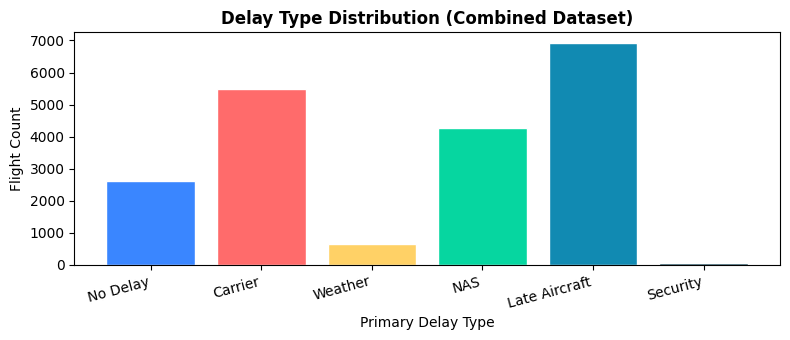

In [42]:
# STEP 4 · Build the target variable — primary delay type per flight
def assign_delay_type(row, min_delay: int) -> int:
    """Return the label (0-5) of the dominant delay type for this flight."""
    vals = {label: row[col] for label, col in DELAY_TYPE_MAP.items()}
    dominant_label = max(vals, key=vals.get)
    return dominant_label if vals[dominant_label] >= min_delay else 0

df["DELAY_TYPE"] = df.apply(
    assign_delay_type, axis=1, min_delay=CONFIG["min_delay_mins"]
)

# Summary table
dist = df["DELAY_TYPE"].value_counts().sort_index()
dist_df = pd.DataFrame({
    "Label": [DELAY_LABELS[k] for k in dist.index],
    "Count": dist.values,
    "Pct":   (dist.values / dist.values.sum() * 100).round(1),
})
print("Class distribution:")
display(dist_df)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#3A86FF","#FF6B6B","#FFD166","#06D6A0","#118AB2","#073B4C"]
ax.bar(dist_df["Label"], dist_df["Count"],
       color=colors[:len(dist_df)], edgecolor="white")
ax.set_title("Delay Type Distribution (Combined Dataset)", fontweight="bold")
ax.set_ylabel("Flight Count")
ax.set_xlabel("Primary Delay Type")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Step 5: Feature Engineering

| Feature Group | Features | Rationale |
|---|---|---|
| Raw temporal | `YEAR`, `MONTH`, `DAY_OF_WEEK`, `DAY_OF_MONTH` | Time-of-year seasonality |
| Cyclical temporal | `MONTH_SIN/COS`, `DOW_SIN/COS` | Preserves circular nature of calendar |
| Encoded categoricals | `CARRIER_ENC`, `ORIGIN_ENC`, `DEST_ENC` | Label-encoded airline/airport codes |
| Delay values | `DEP_DELAY`, `ARR_DELAY`, `NET_DELAY` | Core delay signal |
| Flight metadata | `IS_CANCELLED`, `OP_CARRIER_FL_NUM` | Route/operational proxy |


In [43]:
# STEP 5 · Feature Engineering

# Encode categorical columns
cat_encoders = {}
for col in ["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"]:
    if col in df.columns:
        le = LabelEncoder()
        df[col + "_ENC"] = le.fit_transform(df[col].astype(str))
        cat_encoders[col] = le

# Cyclical encoding for month and day-of-week to capture periodicity
df["MONTH_SIN"] = np.sin(2 * np.pi * df["MONTH"] / 12)
df["MONTH_COS"] = np.cos(2 * np.pi * df["MONTH"] / 12)
df["DOW_SIN"]   = np.sin(2 * np.pi * df["DAY_OF_WEEK"] / 7)
df["DOW_COS"]   = np.cos(2 * np.pi * df["DAY_OF_WEEK"] / 7)

# Binary flag: was the flight cancelled?
df["IS_CANCELLED"] = (df["CANCELLED"] > 0).astype(int)

# Interaction: net delay = departure delay minus arrival delay
df["NET_DELAY"] = df["DEP_DELAY"] - df["ARR_DELAY"]

# Build final feature list
feature_cols = [
    # Raw temporal
    "YEAR", "MONTH", "DAY_OF_WEEK", "DAY_OF_MONTH",
    # Cyclical temporal
    "MONTH_SIN", "MONTH_COS", "DOW_SIN", "DOW_COS",
    # Encoded categoricals
    "OP_UNIQUE_CARRIER_ENC",
    # Delay values
    "DEP_DELAY", "ARR_DELAY", "NET_DELAY",
    # Flight metadata
    "IS_CANCELLED",
]

# Add optional columns if they exist
for col in ["OP_CARRIER_FL_NUM", "ORIGIN_ENC", "DEST_ENC"]:
    if col in df.columns:
        feature_cols.append(col)

X = df[feature_cols].values
y = df["DELAY_TYPE"].values

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

Features (16): ['YEAR', 'MONTH', 'DAY_OF_WEEK', 'DAY_OF_MONTH', 'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS', 'OP_UNIQUE_CARRIER_ENC', 'DEP_DELAY', 'ARR_DELAY', 'NET_DELAY', 'IS_CANCELLED', 'OP_CARRIER_FL_NUM', 'ORIGIN_ENC', 'DEST_ENC']
X shape : (20000, 16)
y shape : (20000,)


## Step 6: Train / Test Split

Stratified split ensures all delay type classes are proportionally represented in both sets.


In [44]:
# STEP 6 · Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

print(f"Train rows : {len(X_train):,}")
print(f"Test rows  : {len(X_test):,}")

# Compute sample weights to compensate for class imbalance
sample_weights_train = (
    compute_sample_weight("balanced", y_train)
    if CONFIG["use_class_weights"] else None
)
print(f"\nClass weights applied: {CONFIG['use_class_weights']}")

Train rows : 16,000
Test rows  : 4,000

Class weights applied: True


## Step 7: Train Model (+ Optional Hyperparameter Tuning)

**Default:** trains with `CONFIG values directly.  
**Tuning:** set 'CONFIG["run_tuning"] = True to run RandomizedSearchCV across 8 hyperparameters before fitting the final model.


In [ ]:
# STEP 7 · Hyperparameter tuning via RandomizedSearchCV

if CONFIG["run_tuning"]:
    print("Running RandomizedSearchCV — this may take several minutes.")
    print(f"Trying {CONFIG['tuning_n_iter']} random configs × {CONFIG['tuning_cv_folds']}-fold CV …\n")

    param_dist = {
        "n_estimators":     [100, 200, 400, 600],
        "learning_rate":    [0.01, 0.05, 0.10, 0.20],
        "max_depth":        [3, 4, 5, 6, 7, 8],
        "min_child_weight": [1, 3, 5, 7],
        "subsample":        [0.60, 0.70, 0.80, 0.90, 1.0],
        "colsample_bytree": [0.60, 0.70, 0.80, 0.90, 1.0],
        "gamma":            [0, 0.05, 0.10, 0.20, 0.50],
        "reg_alpha":        [0, 0.01, 0.10, 0.50, 1.0],
        "reg_lambda":       [0.50, 1.0, 2.0, 5.0],
    }

    base_xgb = XGBClassifier(
        objective="multi:softmax",
        num_class=len(DELAY_LABELS),
        eval_metric="mlogloss",
        use_label_encoder=False,
        tree_method="hist",
        random_state=CONFIG["random_state"],
        verbosity=0,
    )

    cv_inner = StratifiedKFold(
        n_splits=CONFIG["tuning_cv_folds"], shuffle=True,
        random_state=CONFIG["random_state"]
    )

    search = RandomizedSearchCV(
        base_xgb,
        param_distributions=param_dist,
        n_iter=CONFIG["tuning_n_iter"],
        scoring=CONFIG["tuning_scoring"],
        cv=cv_inner,
        n_jobs=-1,
        random_state=CONFIG["random_state"],
        verbose=1,
    )

    search.fit(X_train, y_train, sample_weight=sample_weights_train)

    print(f"\nBest CV {CONFIG['tuning_scoring']} : {search.best_score_:.4f}")
    print("Best params found:")
    best_params_df = pd.DataFrame(
        search.best_params_.items(), columns=["Parameter", "Best Value"]
    )
    display(best_params_df)

    CONFIG.update(search.best_params_)
    model = search.best_estimator_

else:
    print("Skipping tuning — training directly with CONFIG values.")
    print("(Set CONFIG['run_tuning'] = True to enable the sweep.)\n")

    model = XGBClassifier(
        objective="multi:softmax",
        num_class=len(DELAY_LABELS),
        eval_metric="mlogloss",
        use_label_encoder=False,
        tree_method="hist",
        n_estimators=CONFIG["n_estimators"],
        learning_rate=CONFIG["learning_rate"],
        max_depth=CONFIG["max_depth"],
        min_child_weight=CONFIG["min_child_weight"],
        subsample=CONFIG["subsample"],
        colsample_bytree=CONFIG["colsample_bytree"],
        gamma=CONFIG["gamma"],
        reg_alpha=CONFIG["reg_alpha"],
        reg_lambda=CONFIG["reg_lambda"],
        random_state=CONFIG["random_state"],
        verbosity=0,
    )

    model.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )

print("\n Model trained")

# Cross-validation on full dataset
cv = StratifiedKFold(
    n_splits=CONFIG["cv_folds"], shuffle=True,
    random_state=CONFIG["random_state"]
)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"\nCross-Validation F1 Macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Skipping tuning — training directly with CONFIG values.
(Set CONFIG['run_tuning'] = True to enable the sweep.)


 Model trained

Cross-Validation F1 Macro: 0.4757 ± 0.0061


## Step 8: Evaluate Classification Report & Per-Carrier F1


 Classification Report 
               precision    recall  f1-score   support

     No Delay       0.77      0.89      0.82       522
      Carrier       0.50      0.45      0.47      1100
      Weather       0.14      0.25      0.18       131
          NAS       0.88      0.79      0.83       856
Late Aircraft       0.60      0.61      0.61      1382
     Security       0.00      0.00      0.00         9

     accuracy                           0.63      4000
    macro avg       0.48      0.50      0.49      4000
 weighted avg       0.64      0.63      0.63      4000

Accuracy     : 0.6275
F1 Macro     : 0.4862
F1 Weighted  : 0.6309
CV F1 Macro  : 0.4757 ± 0.0061


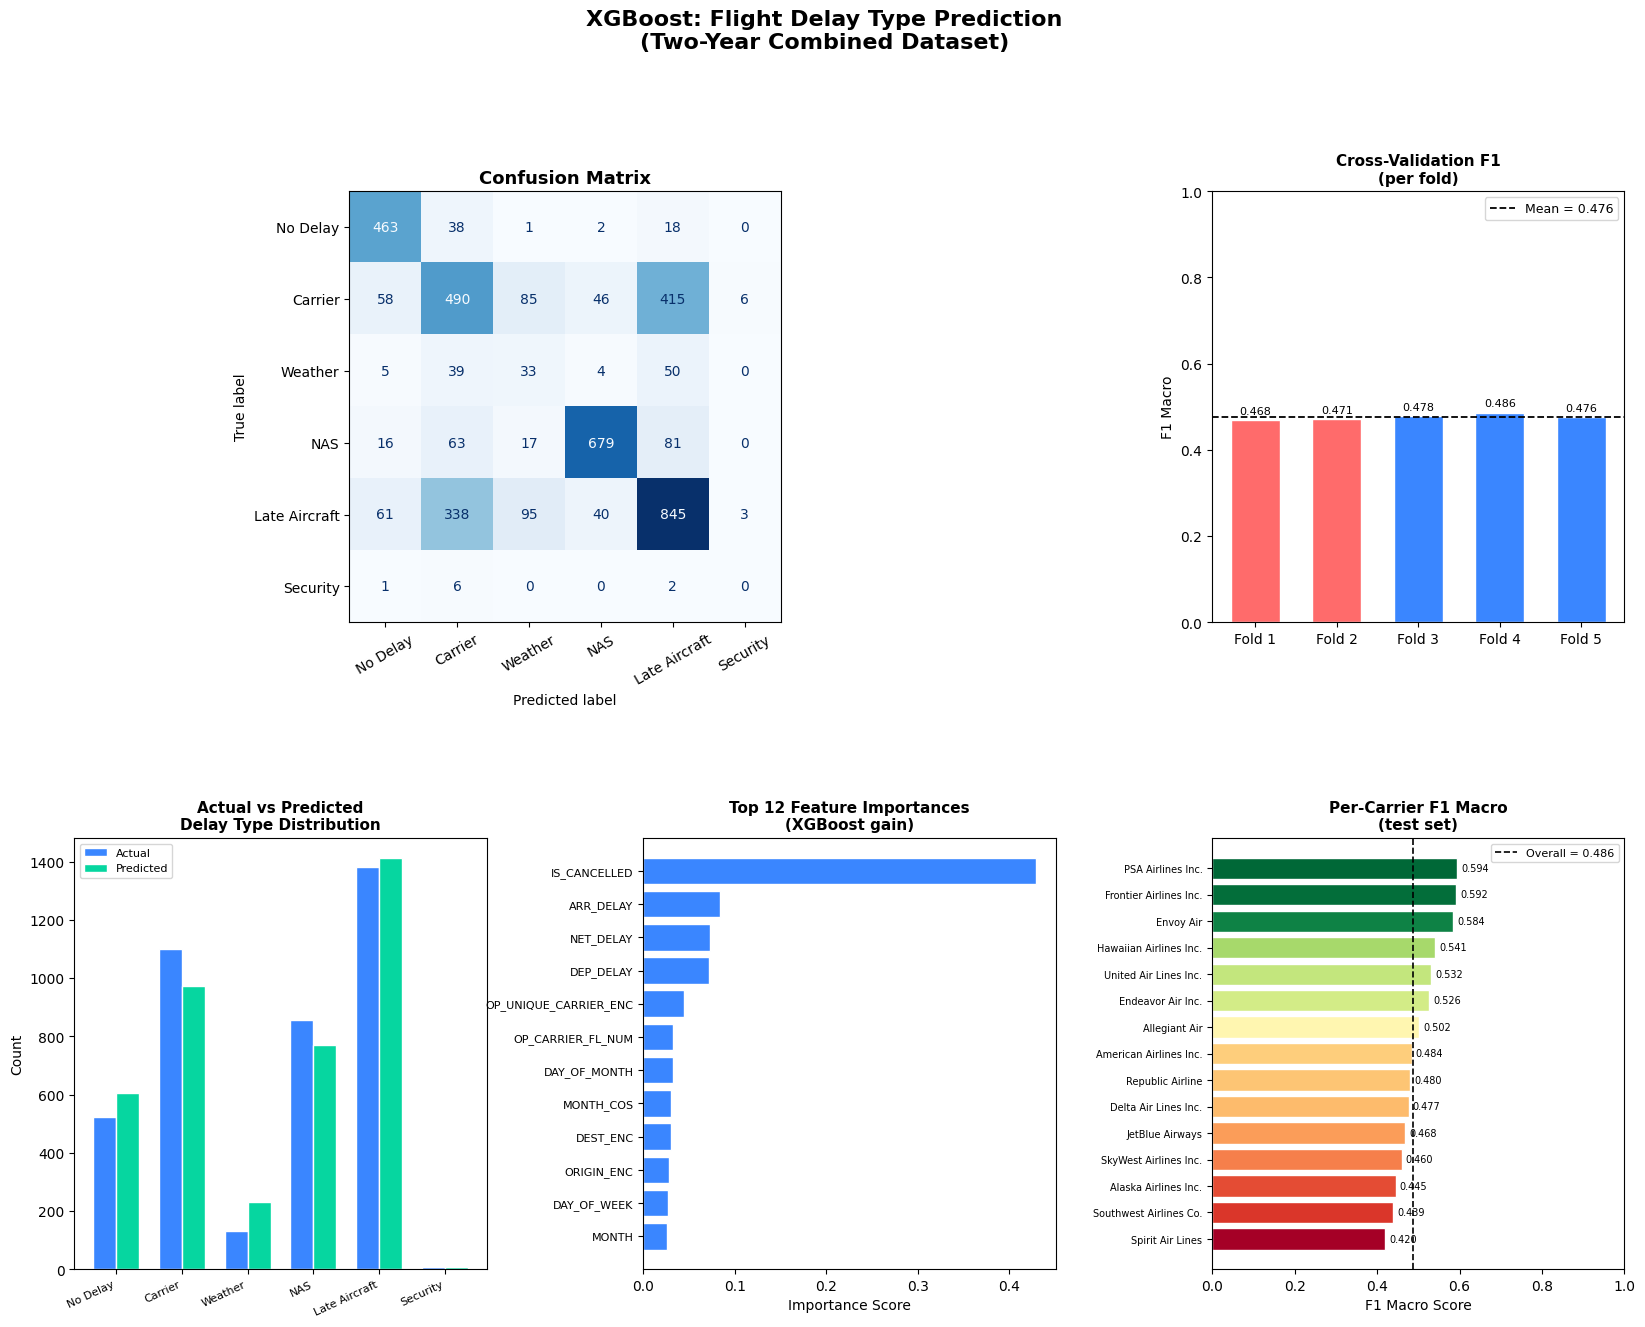


 Plot saved → xgb_delay_results.png


In [50]:
# STEP 8 · Classification metrics
y_pred = model.predict(X_test)

unique_classes = sorted(set(y_test) | set(y_pred))
target_names   = [DELAY_LABELS[c] for c in unique_classes]

acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average="macro",    zero_division=0)
f1_wt  = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(" Classification Report ")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
print(f"Accuracy     : {acc:.4f}")
print(f"F1 Macro     : {f1_mac:.4f}")
print(f"F1 Weighted  : {f1_wt:.4f}")
print(f"CV F1 Macro  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Step 8 ·Visualisations
fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    "XGBoost: Flight Delay Type Prediction\n(Two-Year Combined Dataset)",
    fontsize=16, fontweight="bold", y=1.01
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

# Panel 1 · Confusion Matrix
ax1 = fig.add_subplot(gs[0, :2])
cm   = confusion_matrix(y_test, y_pred, labels=unique_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax1, cmap="Blues", colorbar=False, xticks_rotation=30)
ax1.set_title("Confusion Matrix", fontsize=13, fontweight="bold")

# Panel 2 · Cross-Validation F1 per fold
ax2 = fig.add_subplot(gs[0, 2])
fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
bar_colors  = ["#3A86FF" if s >= cv_scores.mean() else "#FF6B6B" for s in cv_scores]
bars = ax2.bar(fold_labels, cv_scores, color=bar_colors, edgecolor="white", width=0.6)
ax2.axhline(cv_scores.mean(), color="black", linestyle="--", linewidth=1.3,
            label=f"Mean = {cv_scores.mean():.3f}")
ax2.set_ylim(0, 1)
ax2.set_ylabel("F1 Macro")
ax2.set_title("Cross-Validation F1\n(per fold)", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
for bar, val in zip(bars, cv_scores):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=8)

# Panel 3 · Actual vs Predicted Distribution
ax3 = fig.add_subplot(gs[1, 0])
actual_counts    = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()
all_cls = sorted(set(actual_counts.index) | set(predicted_counts.index))
x, w    = np.arange(len(all_cls)), 0.35
ax3.bar(x - w/2, [actual_counts.get(c, 0)    for c in all_cls],
        width=w, label="Actual",    color="#3A86FF", edgecolor="white")
ax3.bar(x + w/2, [predicted_counts.get(c, 0) for c in all_cls],
        width=w, label="Predicted", color="#06D6A0", edgecolor="white")
ax3.set_xticks(x)
ax3.set_xticklabels([DELAY_LABELS[c] for c in all_cls], rotation=25, ha="right", fontsize=8)
ax3.set_title("Actual vs Predicted\nDelay Type Distribution", fontsize=11, fontweight="bold")
ax3.set_ylabel("Count")
ax3.legend(fontsize=8)

# Panel 4 · Top Feature Importances
ax4 = fig.add_subplot(gs[1, 1])
top_n     = min(12, len(feat_imp_df))
top_feats = feat_imp_df.head(top_n)
ax4.barh(top_feats["Feature"][::-1], top_feats["Importance"][::-1],
         color="#3A86FF", edgecolor="white")
ax4.set_title(f"Top {top_n} Feature Importances\n(XGBoost gain)",
              fontsize=11, fontweight="bold")
ax4.set_xlabel("Importance Score")
ax4.tick_params(axis="y", labelsize=8)

# Panel 5 · Per-Carrier F1 Macro — full names from df["CARRIERNAME"]
ax5 = fig.add_subplot(gs[1, 2])
if carrier_f1:
    # Build a code CARRIERNAME map directly from the merged df
    code_to_name = (
        df[["OP_UNIQUE_CARRIER", "CARRIERNAME"]]
        .drop_duplicates()
        .set_index("OP_UNIQUE_CARRIER")["CARRIERNAME"]
        .to_dict()
    )

    # Translate codes to full names, falling back to the raw code if not found
    carrier_f1_named = {
        code_to_name.get(code, code): f1
        for code, f1 in carrier_f1.items()
    }
    sorted_carriers = sorted(carrier_f1_named.items(), key=lambda x: x[1])
    carriers, f1s   = zip(*sorted_carriers)

    span = max(max(f1s) - min(f1s), 1e-6)
    bar_colors = plt.cm.RdYlGn([(f - min(f1s)) / span for f in f1s])
    ax5.barh(carriers, f1s, color=bar_colors, edgecolor="white")
    ax5.set_xlim(0, 1)
    ax5.set_xlabel("F1 Macro Score")
    ax5.set_title("Per-Carrier F1 Macro\n(test set)", fontsize=11, fontweight="bold")
    ax5.axvline(f1_mac, color="black", linestyle="--", linewidth=1.2,
                label=f"Overall = {f1_mac:.3f}")
    ax5.legend(fontsize=8)
    ax5.tick_params(axis="y", labelsize=7)
    for i, (c, f) in enumerate(zip(carriers, f1s)):
        ax5.text(f + 0.01, i, f"{f:.3f}", va="center", fontsize=7)
else:
    ax5.axis("off")
    ax5.text(0.5, 0.5, "Single carrier\nfilter active",
             ha="center", va="center", fontsize=12)

plt.savefig(CONFIG["output_plot"], dpi=150, bbox_inches="tight")
plt.show()
print(f"\n Plot saved → {CONFIG['output_plot']}")

## 9 · Performance Plots

Five panels:
1. **Confusion Matrix** — predicted vs actual delay type
2. **CV F1 per Fold** — stability across cross-validation folds
3. **Actual vs Predicted Distribution** — class balance check
4. **Top Feature Importances** — what drives the model
5. **Per-Carrier F1** — which airlines are easiest/hardest to classify


## 10 · Model Summary


In [47]:
# Final summary table
summary = pd.DataFrame({
    "Metric": [
        "Dataset (2024)", "Dataset (2023)", "Total Rows",
        "Features", "Classes",
        "Accuracy", "F1 Macro", "F1 Weighted",
        "CV F1 Mean", "CV F1 Std",
        "n_estimators", "learning_rate", "max_depth",
    ],
    "Value": [
        f"{len(df_2024):,}", f"{len(df_2023):,}", f"{len(df):,}",
        len(feature_cols), len(unique_classes),
        f"{acc:.4f}", f"{f1_mac:.4f}", f"{f1_wt:.4f}",
        f"{cv_scores.mean():.4f}", f"{cv_scores.std():.4f}",
        CONFIG["n_estimators"], CONFIG["learning_rate"], CONFIG["max_depth"],
    ]
})
display(summary)

,Metric,Value
0,Dataset (2024),"10,000"
1,Dataset (2023),"10,000"
2,Total Rows,"20,000"
3,Features,16
4,Classes,6
5,Accuracy,0.6275
6,F1 Macro,0.4862
7,F1 Weighted,0.6309
8,CV F1 Mean,0.4757
9,CV F1 Std,0.0061


## 11 · Tuning Guide

All parameters are set in `CONFIG` in **Cell 1**. Change them there and re-run from Cell 1 downward.

| Parameter | Default | Effect |
|-----------|---------|--------|
| `n_estimators` | 400 | More rounds → better fit; use with lower `learning_rate` |
| `learning_rate` | 0.05 | Lower → slower convergence but often better generalisation |
| `max_depth` | 6 | Deeper trees capture more patterns but risk overfitting |
| `min_child_weight` | 3 | Higher → more conservative splits, less overfit |
| `subsample` | 0.80 | Row fraction per tree; lower adds regularisation |
| `colsample_bytree` | 0.80 | Feature fraction per tree; lower adds regularisation |
| `gamma` | 0.1 | Minimum loss reduction to make a split; raise to prune |
| `reg_alpha` | 0.1 | L1 penalty — encourages sparse feature weights |
| `reg_lambda` | 1.0 | L2 penalty — shrinks weights smoothly |
| `min_delay_mins` | 15 | Raise to 30 to sharpen class boundaries |
| `carrier_filter` | `None` | Set to `"WN"`, `"AA"` etc. for a carrier-specific model |
| `run_tuning` | `False` | Set `True` to let RandomizedSearchCV find the best params |

```


In [48]:
### Quick experiments
# 1 · More power: more trees, smaller steps
CONFIG["n_estimators"]  = 800
CONFIG["learning_rate"] = 0.02

# 2 · Auto-tune all hyperparameters
CONFIG["run_tuning"]    = True
CONFIG["tuning_n_iter"] = 30   # more configs = better result but slower

# 3 · Train on a single carrier only
CONFIG["carrier_filter"] = "WN"  # Southwest

# 4 · Tighten the "No Delay" threshold
CONFIG["min_delay_mins"] = 30